# Week 2 Project — OBD-II Vehicle Data Analysis

This notebook combines the main topics of Week 2 using the OBD-II vehicle dataset:

- Descriptive statistics
- Probability
- Linear algebra
- Exploratory data analysis
- Outlier detection
- Correlation and data storytelling

## Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../OBDii_data.csv", low_memory=False)

print(df.shape)
df.head()

(60439, 33)


,TIMESTAMP,MARK,MODEL,CAR_YEAR,ENGINE_POWER,AUTOMATIC,VEHICLE_ID,BAROMETRIC_PRESSURE(KPA),ENGINE_COOLANT_TEMP,FUEL_LEVEL,...,THROTTLE_POS,DTC_NUMBER,TROUBLE_CODES,TIMING_ADVANCE,EQUIV_RATIO,MIN,HOURS,DAYS_OF_WEEK,MONTHS,YEAR
0,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,9%","1,0%",13.0,16.0,2.0,8.0,2017.0
1,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,5%","1,0%",13.0,16.0,2.0,8.0,2017.0
2,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"57,3%","1,0%",13.0,16.0,2.0,8.0,2017.0
3,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,5%","1,0%",13.0,16.0,2.0,8.0,2017.0
4,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,9%","1,0%",13.0,16.0,2.0,8.0,2017.0


## Inspect and clean the data

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60439 entries, 0 to 60438
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TIMESTAMP                    47514 non-null  float64
 1   MARK                         47459 non-null  str    
 2   MODEL                        47459 non-null  str    
 3   CAR_YEAR                     47459 non-null  float64
 4   ENGINE_POWER                 47459 non-null  str    
 5   AUTOMATIC                    47459 non-null  str    
 6   VEHICLE_ID                   47514 non-null  str    
 7   BAROMETRIC_PRESSURE(KPA)     10212 non-null  float64
 8   ENGINE_COOLANT_TEMP          33964 non-null  float64
 9   FUEL_LEVEL                   2994 non-null   str    
 10  ENGINE_LOAD                  30972 non-null  str    
 11  AMBIENT_AIR_TEMP             3619 non-null   float64
 12  ENGINE_RPM                   33859 non-null  float64
 13  INTAKE_MANIFOLD_PRESSURE   

In [3]:
print("Empty rows:", df.isna().all(axis=1).sum())
print("Empty columns:", df.isna().all(axis=0).sum())
print("Duplicated rows:", df.duplicated().sum())

df.dropna(how="all", inplace=True)
df.dropna(how="all", axis=1, inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after cleaning:", df.shape)

Empty rows: 12925
Empty columns: 0
Duplicated rows: 12924
Shape after cleaning: (47514, 33)


In [4]:
df.isna().sum().sort_values(ascending=False).head(10)

FUEL_PRESSURE                  47376
FUEL_LEVEL                     44520
AMBIENT_AIR_TEMP               43895
BAROMETRIC_PRESSURE(KPA)       37302
MAF                            35686
EQUIV_RATIO                    35618
ENGINE_RUNTIME                 35612
TROUBLE_CODES                  35589
LONG TERM FUEL TRIM BANK 2     34444
SHORT TERM FUEL TRIM BANK 2    34444
dtype: int64

Some sensors contain missing values because not every vehicle reports all OBD-II measurements. For this reason, each analysis uses the available values from the required columns.

## Select the main vehicle features

In [5]:
cars = df[
    [
        "ENGINE_RPM",
        "SPEED",
        "ENGINE_COOLANT_TEMP",
        "AIR_INTAKE_TEMP",
        "BAROMETRIC_PRESSURE(KPA)",
        "INTAKE_MANIFOLD_PRESSURE"
    ]
].copy()

cars.head()

,ENGINE_RPM,SPEED,ENGINE_COOLANT_TEMP,AIR_INTAKE_TEMP,BAROMETRIC_PRESSURE(KPA),INTAKE_MANIFOLD_PRESSURE
0,1009.0,0.0,80.0,59.0,100.0,49.0
1,1003.0,0.0,80.0,59.0,100.0,52.0
2,995.0,0.0,80.0,59.0,100.0,51.0
3,1004.0,0.0,80.0,60.0,100.0,51.0
4,1005.0,0.0,80.0,60.0,100.0,49.0


## Descriptive statistics

In [6]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
ENGINE_RPM,33859.0,1517.803391,613.937502,438.0,906.0,1487.0,1957.0,3816.0
SPEED,46529.0,24.743751,29.294017,0.0,0.0,14.0,42.0,143.0
ENGINE_COOLANT_TEMP,33964.0,81.772023,10.910737,22.0,78.0,85.0,88.0,105.0
AIR_INTAKE_TEMP,34352.0,41.243101,8.517170,23.0,35.0,40.0,47.0,80.0
BAROMETRIC_PRESSURE(KPA),10212.0,96.404328,2.865433,89.0,95.0,96.0,100.0,101.0
INTAKE_MANIFOLD_PRESSURE,25089.0,47.379728,20.202995,13.0,32.0,43.0,58.0,101.0


### Speed statistics

In [7]:
speed = cars["SPEED"].dropna()

mean_speed = speed.mean()
median_speed = speed.median()
mode_speed = speed.mode()[0]
speed_range = speed.max() - speed.min()
speed_variance = speed.var()
speed_std = speed.std()

q1 = speed.quantile(0.25)
q3 = speed.quantile(0.75)
iqr = q3 - q1

print("Mean:", round(mean_speed, 2))
print("Median:", round(median_speed, 2))
print("Mode:", round(mode_speed, 2))
print("Range:", round(speed_range, 2))
print("Variance:", round(speed_variance, 2))
print("Standard deviation:", round(speed_std, 2))
print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))

Mean: 24.74
Median: 14.0
Mode: 0.0
Range: 143.0
Variance: 858.14
Standard deviation: 29.29
Q1: 0.0
Q3: 42.0
IQR: 42.0


The speed statistics describe the center and spread of the observations. The mean and median show the typical speed, while the standard deviation and IQR show how much the values vary.

## Probability using vehicle readings

In [8]:
probability_data = df[
    ["SPEED", "ENGINE_RPM"]
].dropna()

high_speed = probability_data["SPEED"] > 60
high_rpm = probability_data["ENGINE_RPM"] > 2500

p_high_speed = high_speed.mean()
p_high_rpm = high_rpm.mean()
p_both = (high_speed & high_rpm).mean()

p_high_speed_given_high_rpm = p_both / p_high_rpm

print("P(Speed > 60):", round(p_high_speed, 3))
print("P(RPM > 2500):", round(p_high_rpm, 3))
print("P(Speed > 60 and RPM > 2500):", round(p_both, 3))
print(
    "P(Speed > 60 | RPM > 2500):",
    round(p_high_speed_given_high_rpm, 3)
)

P(Speed > 60): 0.184
P(RPM > 2500): 0.066
P(Speed > 60 and RPM > 2500): 0.054
P(Speed > 60 | RPM > 2500): 0.819


This section applies experimental probability to real observations. The conditional probability shows how often high speed occurs when the engine RPM is also high.

## Linear algebra

In [9]:
features = [
    "ENGINE_RPM",
    "SPEED",
    "ENGINE_COOLANT_TEMP"
]

samples = df[features].dropna().head(3).to_numpy()

weights = np.array([0.003, 0.5, 0.2])

print("Samples:")
print(samples)
print("Shape:", samples.shape)

first_prediction = np.dot(samples[0], weights)
predictions = samples @ weights

print("First prediction:", round(first_prediction, 2))
print("All predictions:", predictions.round(2))

Samples:
[[1009.    0.   80.]
 [1003.    0.   80.]
 [ 995.    0.   80.]]
Shape: (3, 3)
First prediction: 19.03
All predictions: [19.03 19.01 18.98]


Each row is represented as a feature vector. The dot product gives one result for the first sample, while matrix multiplication calculates a result for all three samples at once.

These values are only examples of how a linear model combines features and weights; they are not trained predictions.

## Feature distributions

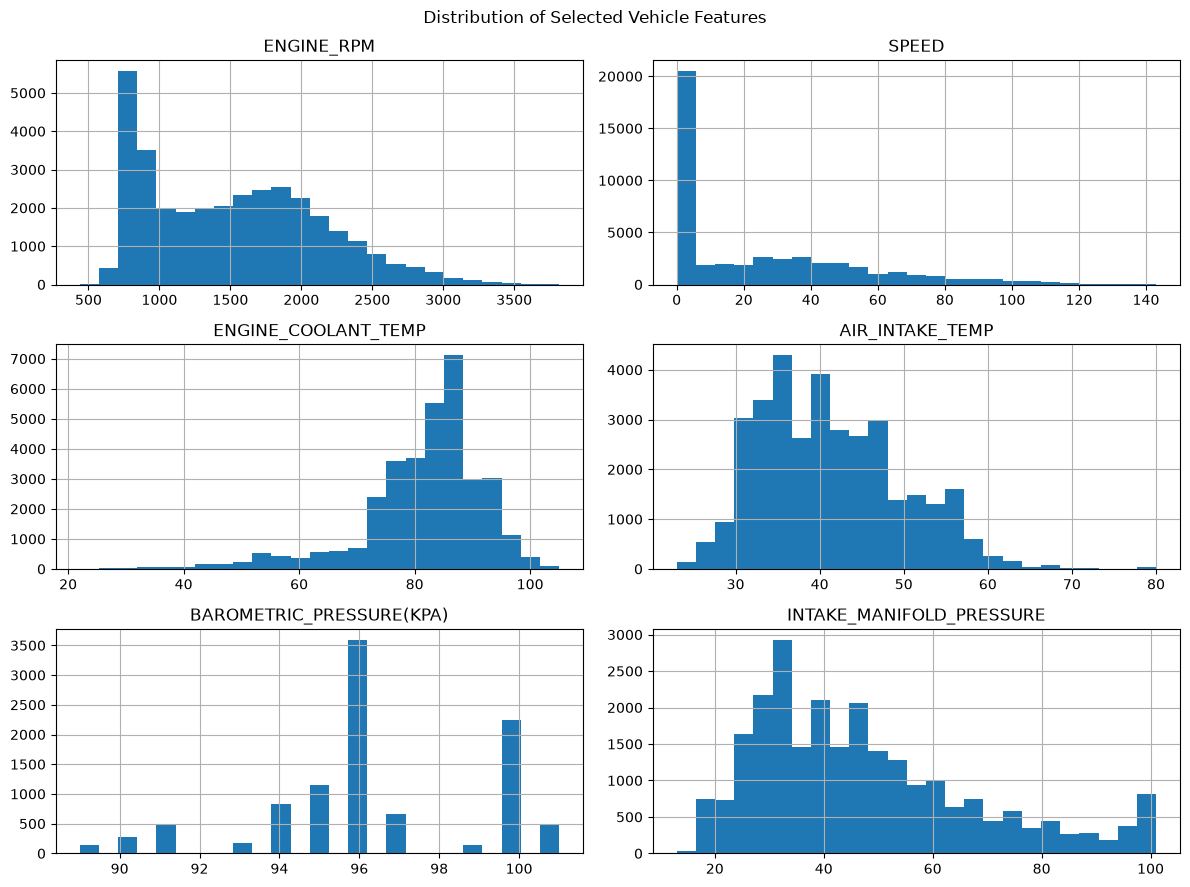

In [10]:
cars.hist(figsize=(12, 9), bins=25)
plt.suptitle("Distribution of Selected Vehicle Features")
plt.tight_layout()
plt.show()

The histograms show that the selected vehicle measurements have different ranges and distribution shapes. Speed and engine RPM have wider variation than most temperature and pressure features.

## Box plots

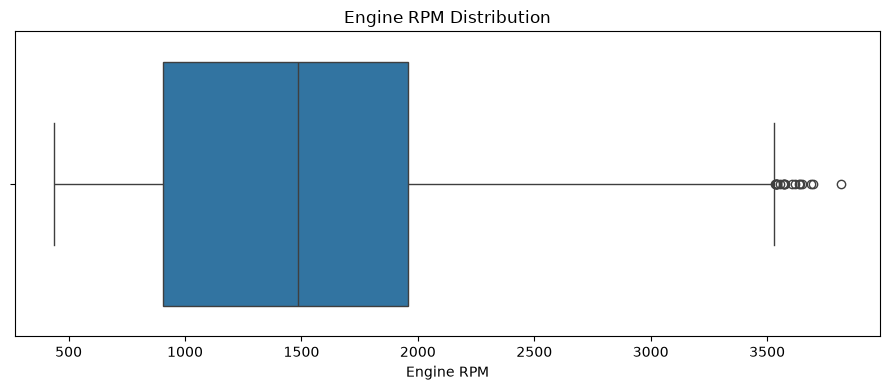

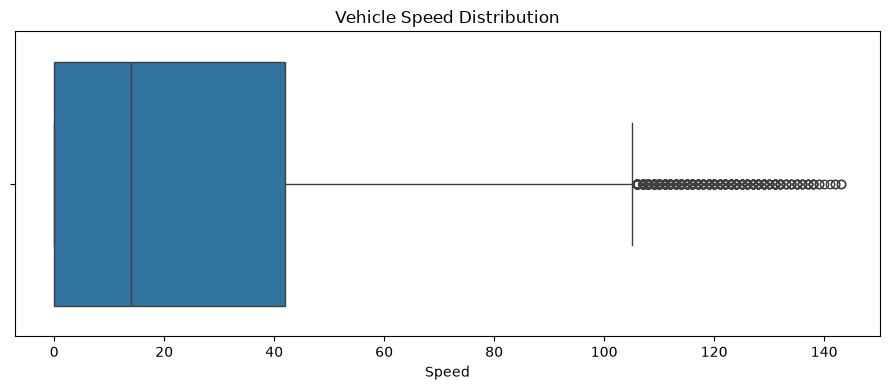

In [11]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=cars, x="ENGINE_RPM")
plt.title("Engine RPM Distribution")
plt.xlabel("Engine RPM")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(data=cars, x="SPEED")
plt.title("Vehicle Speed Distribution")
plt.xlabel("Speed")
plt.tight_layout()
plt.show()

## Detect RPM outliers using IQR

In [12]:
rpm = cars["ENGINE_RPM"].dropna()

rpm_q1 = rpm.quantile(0.25)
rpm_q3 = rpm.quantile(0.75)
rpm_iqr = rpm_q3 - rpm_q1

lower_bound = rpm_q1 - 1.5 * rpm_iqr
upper_bound = rpm_q3 + 1.5 * rpm_iqr

rpm_outliers = rpm[
    (rpm < lower_bound) |
    (rpm > upper_bound)
]

outlier_percentage = len(rpm_outliers) / len(rpm) * 100

print("Q1:", round(rpm_q1, 2))
print("Q3:", round(rpm_q3, 2))
print("IQR:", round(rpm_iqr, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of outliers:", len(rpm_outliers))
print("Outlier percentage:", round(outlier_percentage, 2), "%")

Q1: 906.0
Q3: 1957.0
IQR: 1051.0
Lower bound: -670.5
Upper bound: 3533.5
Number of outliers: 19
Outlier percentage: 0.06 %


The RPM values outside the IQR bounds are considered potential outliers. They are kept because high RPM may represent real acceleration or high engine load rather than an incorrect reading.

## Engine RPM and speed

Correlation between RPM and speed: 0.84


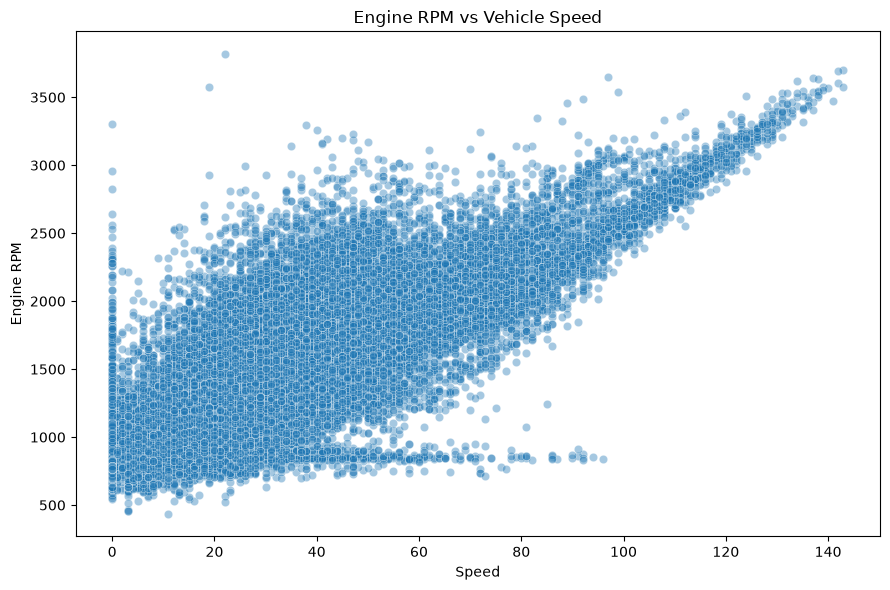

In [13]:
rpm_speed = df[
    ["ENGINE_RPM", "SPEED"]
].dropna()

rpm_speed_corr = rpm_speed.corr().loc[
    "ENGINE_RPM",
    "SPEED"
]

print(
    "Correlation between RPM and speed:",
    round(rpm_speed_corr, 2)
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rpm_speed,
    x="SPEED",
    y="ENGINE_RPM",
    alpha=0.4
)

plt.title("Engine RPM vs Vehicle Speed")
plt.xlabel("Speed")
plt.ylabel("Engine RPM")
plt.tight_layout()
plt.show()

Engine RPM and vehicle speed show a clear positive relationship. The relationship is not perfect because gear selection, traffic, road conditions, and driving behavior also affect the readings.

## Speed comparison between vehicle models

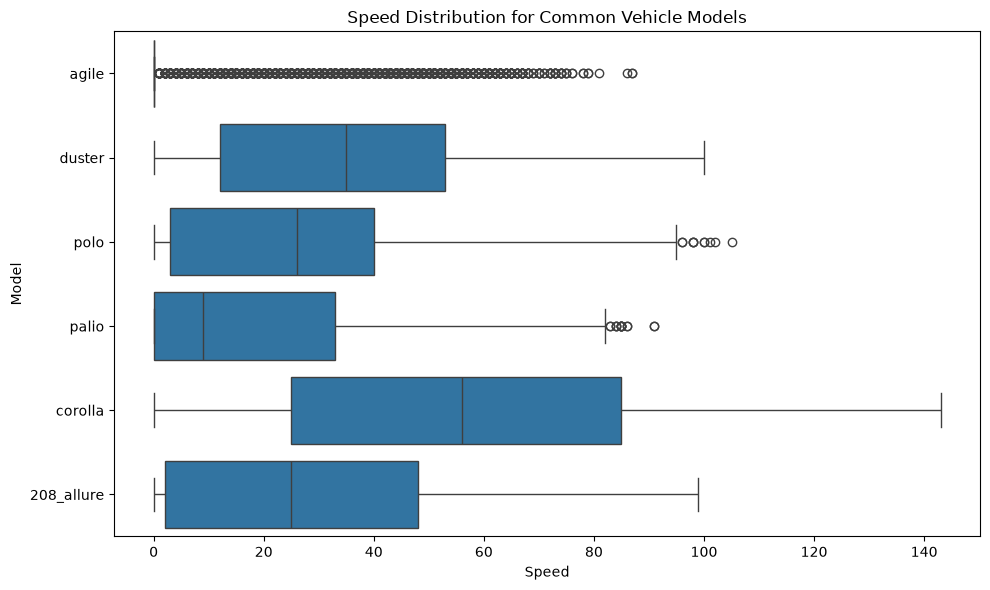

In [14]:
top_models = df["MODEL"].value_counts().head(6).index

model_speed = df[
    df["MODEL"].isin(top_models)
][["MODEL", "SPEED"]].dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=model_speed,
    x="SPEED",
    y="MODEL"
)

plt.title("Speed Distribution for Common Vehicle Models")
plt.xlabel("Speed")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

The speed distributions are different between some vehicle models. These differences may also be affected by the route, traffic, and number of readings collected from each vehicle.

## Correlation matrix

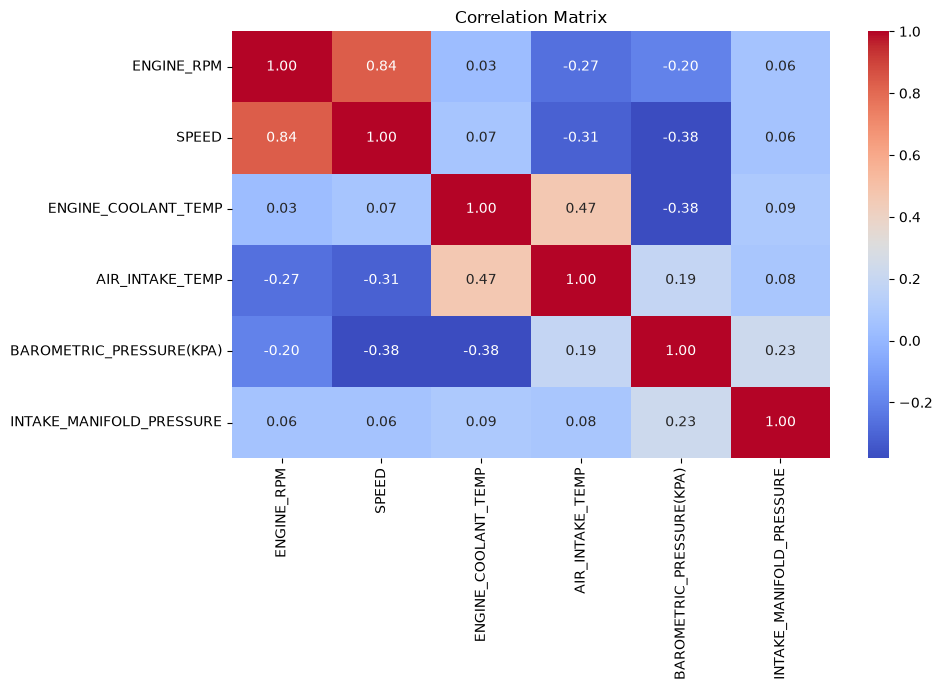

In [15]:
corr = cars.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [16]:
corr["SPEED"].sort_values(ascending=False)

SPEED                       1.000000
ENGINE_RPM                  0.835143
ENGINE_COOLANT_TEMP         0.067198
INTAKE_MANIFOLD_PRESSURE    0.061665
AIR_INTAKE_TEMP            -0.311985
BAROMETRIC_PRESSURE(KPA)   -0.380323
Name: SPEED, dtype: float64

The correlation matrix helps identify the features that move together. Engine RPM has a strong positive relationship with speed, while some temperature and pressure features have weaker relationships.

Correlation describes a relationship between variables, but it does not prove that one variable causes the other.

## Pairplot

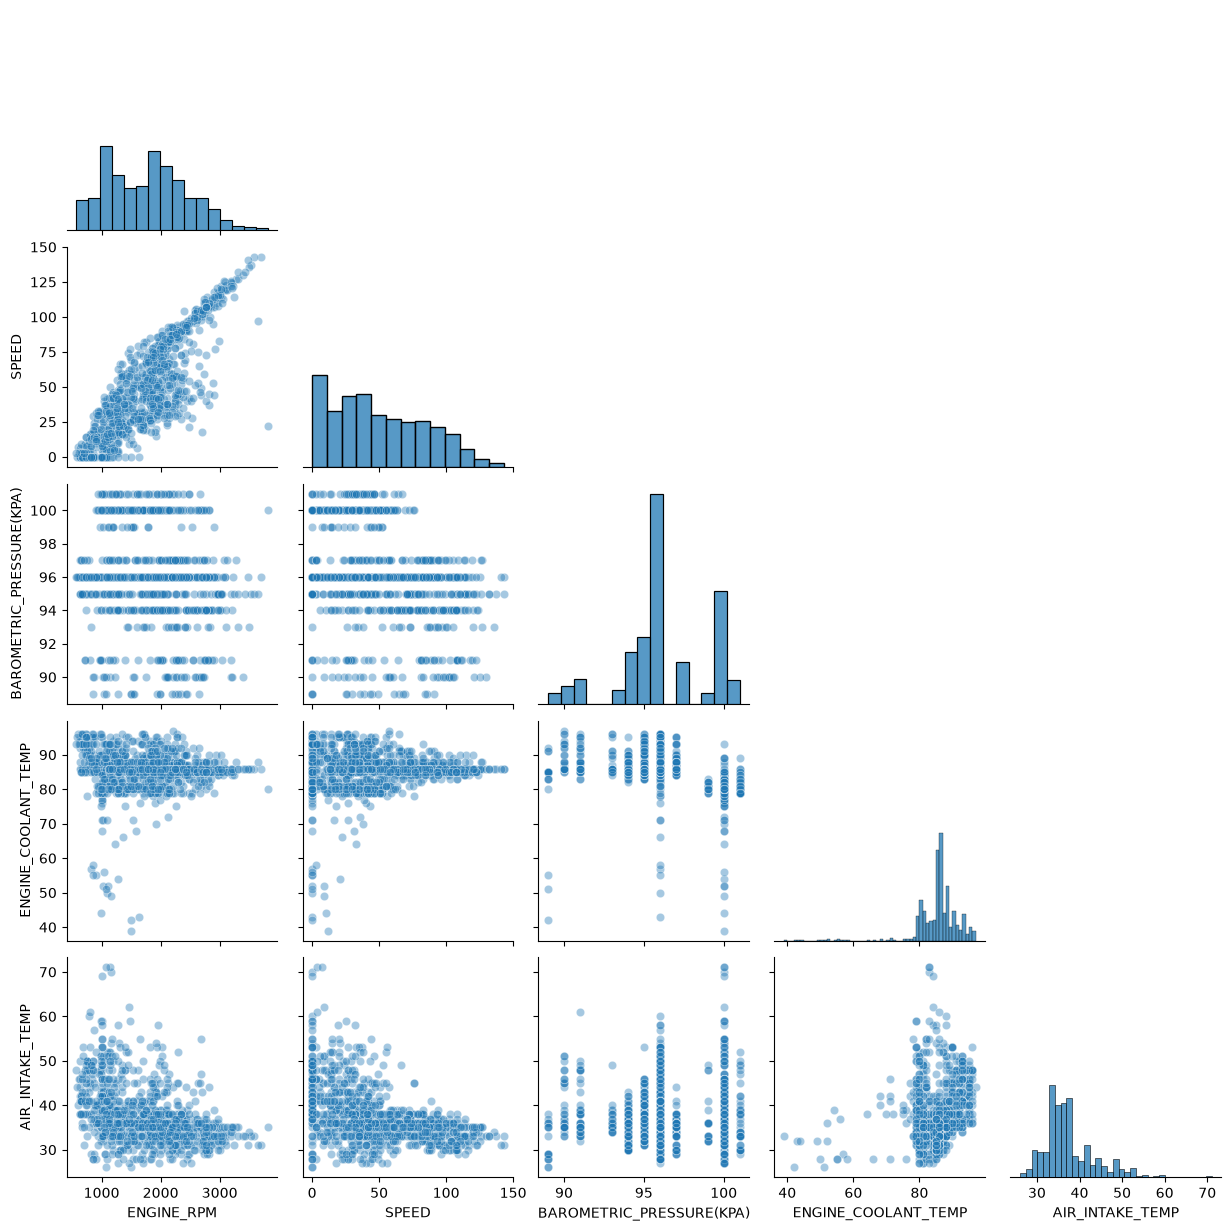

In [17]:
pair_data = df[
    [
        "ENGINE_RPM",
        "SPEED",
        "BAROMETRIC_PRESSURE(KPA)",
        "ENGINE_COOLANT_TEMP",
        "AIR_INTAKE_TEMP"
    ]
].dropna()

pair_data = pair_data.sample(
    min(1000, len(pair_data)),
    random_state=40
)

sns.pairplot(
    pair_data,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.4}
)

plt.show()

The pairplot confirms the relationship between RPM and speed and makes it easier to compare the selected vehicle measurements together.

## Final conclusion

The OBD-II dataset contains useful information about vehicle speed, engine RPM, temperature, and pressure.

The project applied descriptive statistics, probability, vectors and matrices, outlier detection, bivariate analysis, and correlation analysis to the same vehicle dataset.

The strongest visible relationship is between engine RPM and vehicle speed. Some RPM values were detected as potential outliers, but they were kept because they may represent real driving conditions.

Before using this data in a machine learning model, missing values should be handled carefully, features may need scaling, and highly related measurements should be reviewed.